<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB_6_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

## **The Problem**

Many treatments of CART for regression describe the split selection process in different ways. Below are three frequently cited formulations. Suppose we have a dataset with features $X$ and target $y$, and we have a partially built tree $T$. We seek to choose the next region (denoted `Parent` in what follows) to split: the feature $X_j$ and the threshold $t$ to split the data into two child regions $R_1(X_j, t)$ and $R_2(X_j, t)$. Denote by $\bar{y}_{R_m}$ the mean of targets within region $R_m$, with $m=1,2$.

1. **Local RSS Minimization**  
   We select the `Parent`, the feature and threshold that minimize the **sum of squared errors** in the two resulting child nodes:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmin}_{Parent, X_j, t} \sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2.
   $$

2. **RSS Gain Maximization**  

   It is also a local method, looking only at a `Parent` and two child nodes.

   We select the `Parent`, the feature and threshold that maximize the **reduction** in RSS, computed by subtracting the RSS of the two child nodes from the RSS in the parent node:
   $$
   (Parent^*, X_j^*, t^*) = \text{argmax}_{Parent, X_j, t} \Bigl\{
   \underbrace{\sum_{i : x_i \in \text{Parent}} (y_i - \bar{y})^2}_{\text{Parent RSS}}
   \;-\;
   \underbrace{\sum_{m=1}^{2} \sum_{i : x_i \in R_m(X_j, t)} (y_i - \bar{y}_{R_m})^2}_{\text{Children RSS}}
   \Bigr\}.
   $$

3. **Total RSS Minimization**  

   This formulation need somewhat more formal treatment.

   For a dataset $\{(x_i, y_i)\}_{i=1}^N$ with features $X$ and target $y$, let $T$ be the current tree.

   For any split of leaf $P$ on feature $X_j$ at threshold $t$, define $T(P, X_j, t)$ as the new tree obtained by splitting leaf $P$ of $T$ into two leaves $R_1(X_j, t)$ and $R_2(X_j, t)$.
   
   Let $\mathrm{Leaves}(T(P, X_j, t))$ be the set of all leaf indices in this new tree. For each leaf $m \in \mathrm{Leaves}(T(P, X_j, t))$, define:
   $$
   R_m = \{\, i \,\mid\, x_i \text{ ends in leaf } m\}.
   $$

   $R_m$ set collects all data indices $i$ whose feature vector $x_i$ is classified into the leaf node $m$ when passed through the tree $T(P, X_j,t)$. In other words, each leaf node $m$ in $T(P, X_j, t)$ corresponds to a unique path of splits, and any data point $x_i$ that follows that path is assigned to the leaf $m$; hence, it belongs to $R_m$.

   $R_m$ sets for all leafs $m \in \mathrm{Leaves}(T(X_j, t))$ define a partition of all indices.

   Then the objective of **minimizing total Residual Sum of Squares (total RSS)** is stated as:
   $$
   (P^*, X_j^*, t^*) = \text{argmin}_{P, X_j, t} \sum_{m \in \mathrm{Leaves}(T(P, X_j, t))}
   \sum_{i \in R_m} \Bigl(y_i - \overline{y}_{R_m}\Bigr)^2,
   $$
   where
   $$
   \overline{y}_{R_m} = \frac{1}{\lvert R_m \rvert}
   \sum_{i \in R_m} y_i
   $$
   is the mean response in leaf $m$.

## **Research Questions**

   1. **Equivalence Analysis**  
   Determine whether the above formulations are equivalent or if they can yield different split choices. Specifically:
   - Are *local RSS minimization* and *RSS gain maximization* equivalent?
   - Does *total RSS minimization* coincide with either of these two, or is it distinct?
   
  2. **Empirical Experiment**  
   Design and conduct a Python experiment to determine which of these formulations is implemented in `scikit-learn` in `DecisionTreeRegressor`. Present numerical results and plots to support your conclusion.


# Equivalence analysis

First of all let's show how local $RSS$ minimization differs from $RSS$ gain maximization.

Local $RSS$ minimization chooses a parent node and a split in a way to obtain the most homogenous child nodes. It will prioritize splitting already quite good leaves over diverse ones if it means that the child nodes will be perfectly divided.

$RSS$ gain maximization on the other hand, makes the split based on how much the error drops after it. It takes to account not only the resulting child leaves but also the previous erorr of the relevant parent. It will not split leaves that are almost perfect to make them perfect when there are more messy ones that are possible to improve.

Ilustration of the difference between these two approaches will be given in the next section.

Having explained the difference between local $RSS$ minimization and gain maximization, let's now show the equivalence of gain maximization and total $RSS$ maximization.

Let's assume that we have a given tree with leaves $\{L_1, L_2, \dots, L_n\}$
and their $RSS$ errors $\{e_1, e_2, \dots, e_n\}$ respectively. Let's denote a split of $L_k$ by its child nodes $\{L^{\alpha}_{k, 1}, L^{\alpha}_{k, 2}\}$ (and their errors $\{e^{\alpha}_{k, 1}, e^{\alpha}_{k, 2}\}$) where $\alpha \in A_k$ - a set of all possible splits of $L_k$.

$RSS$ gain maximization can be formulated as:
$$argmax_{k, \alpha \in A_k} \{e_k - (e^{\alpha}_{k, 1} + e^{\alpha}_{k, 2})\}$$

Total RSS minimization problem can be formulated as follows.
$$argmin_{k, \alpha \in A_k} \{\text{Total error after split } \alpha\}$$
Total error of the given tree (before our split) is:
$$\sum_{i=1}^n{e_i}.$$
Total error of the tree after partition $\alpha \in A_k$:
$$\left(\sum_{i=1}^n{e_i}\right) - e_k + (e^{\alpha}_{k, 1} + e^{\alpha}_{k, 2})$$
Thus the minimization problem is:
$$argmin_{k, \alpha \in A_k} {\left(\sum_{i=1}^n{e_i}\right)- e_k + (e^{\alpha}_{k, 1} + e^{\alpha}_{k, 2})}$$
Since the first term is constant, the problem is equivalent to:
$$argmin_{k, \alpha \in A_k} \{- e_k + (e^{\alpha}_{k, 1} + e^{\alpha}_{k, 2})\}$$
And of course this is the same as:
$$argmax_{k, \alpha \in A_k} \{e_k - (e^{\alpha}_{k, 1} + e^{\alpha}_{k, 2})\}$$
Which is the $RSS$ gain maximization.


In summary, maximizing $RSS$ gain is the same as minimizing total $RSS$ but different from minimizing local $RSS$.

# Empirical experiment

Let's conduct an experiment to determine which rule is implemented as 'squared_error' in scikit-learn.

We are going to need an artificial dataset consisting of two binary features and a target.

In [3]:
data = np.array([[0, 0, 0],
                [0, 0, 0],
                [0, 0, 0],
                [0, 0, 0],
                [0, 1, 1],
                [1, 0, 1000],
                [1, 0, 1000],
                [1, 0, 1500],
                [1, 1, 2000],
                [1, 1, 2000]])

X = data[:, :-1]
y = data[:, -1]

Let's fit the dataset into a simple regression tree of depth one.

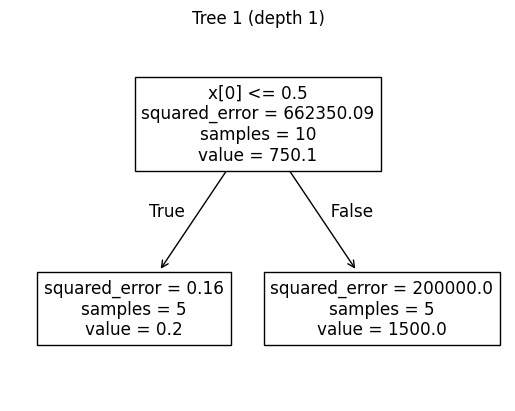

In [4]:
tree1 = DecisionTreeRegressor(criterion= "squared_error",
                              random_state= 42,
                              max_depth= 1)

tree1.fit(X, y)

plot_tree(tree1)
plt.title("Tree 1 (depth 1)")
plt.show()

In [5]:
# Observations partition in the first tree
df1 = pd.DataFrame(data= data, columns= ["Feature 1", "Feature 2", "Target"])
df1["Tree1"] = np.where(tree1.predict(X) == 0.2, "Leaf 1", "Leaf 2")
df1

,Feature 1,Feature 2,Target,Tree1
0,0,0,0,Leaf 1
1,0,0,0,Leaf 1
2,0,0,0,Leaf 1
3,0,0,0,Leaf 1
4,0,1,1,Leaf 1
5,1,0,1000,Leaf 2
6,1,0,1000,Leaf 2
7,1,0,1500,Leaf 2
8,1,1,2000,Leaf 2
9,1,1,2000,Leaf 2


The algorithm devided the observations into two groups based on the first feature.

Leaf 1 consists of observations where $[Feature_1 < 0.5]$ and their target values are {0,0,0,0,1}, $error = 0.16$.

Leaf 2 consists of observations where $[Feature_1 > 0.5]$ and their target values are $\{1000,1000,1500,2000,2000\}$, $error = 200000$.

The first leaf is almost homogenous - its error is close to zero, while the error of the second leaf is large. On the other hand, the first leaf is easily divisible into two leaves both of $error 0$ and the second is not.

We have only the second feature left and condition $[Feature_2 < 0.5]$ would divide the first leaf into groups with target values $\{0,0,0,0\}$ and $\{1\}$ resulting in their joint $error = 0$. No division of the second leaf is able to achieve that, because it consists of two observations with the same features but different targets ($Feature_1 = 1$, $Feature_2 = 0$ gives sometimes $1000$, sometimes $1500$).

In a scenario where only 3 leaves are allowed, an algorithm that proritizes reducing local $RSS$ would split the first leaf to obtain a complete purity in its children nodes. Let's perform the experiment.


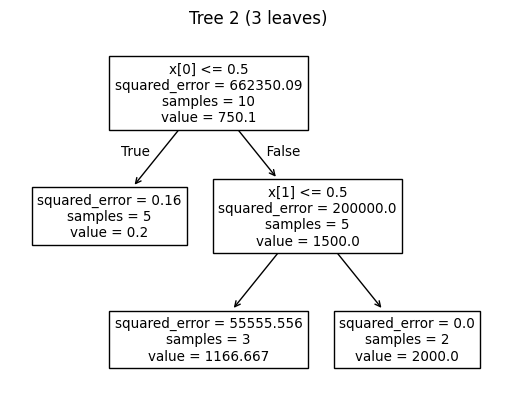

In [6]:
tree2 = DecisionTreeRegressor(criterion= "squared_error",
                              random_state= 42,
                              max_leaf_nodes= 3)

tree2.fit(X, y)

plot_tree(tree2)
plt.title("Tree 2 (3 leaves)")
plt.show()

In [7]:
# Observations partition in the second tree
df2 = pd.DataFrame(data= data, columns= ["Feature 1", "Feature 2", "Target"])
df2["Tree1"] = pd.Series(tree2.predict(X)).map({0.2 : "Leaf 1", 2000 : "Leaf 3"}).fillna("Leaf 2")
df2

,Feature 1,Feature 2,Target,Tree1
0,0,0,0,Leaf 1
1,0,0,0,Leaf 1
2,0,0,0,Leaf 1
3,0,0,0,Leaf 1
4,0,1,1,Leaf 1
5,1,0,1000,Leaf 2
6,1,0,1000,Leaf 2
7,1,0,1500,Leaf 2
8,1,1,2000,Leaf 3
9,1,1,2000,Leaf 3


The regressor chose the second leaf for a split, which means that it is optimized for a total $RSS$ minimization (equivalently gain maximiaztion) rather than a local one. It is an example that proves that these two approaches are in fact different.

The resulting child nodes are not as homogenous as they could be after splitting of the first leaf but the total $error$ of the tree droped far more substantially.

For reference, a full tree is presented below.

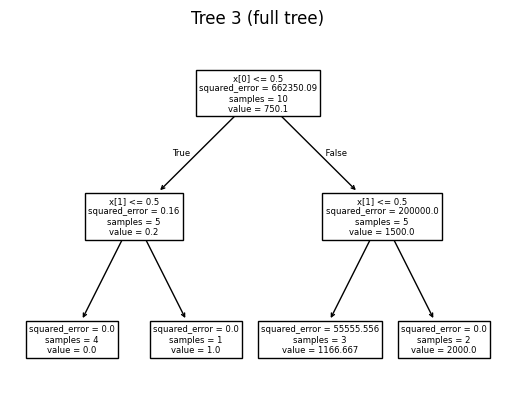

In [8]:
tree3 = DecisionTreeRegressor(criterion= "squared_error",
                              random_state= 42)

tree3.fit(X, y)

plot_tree(tree3)
plt.title("Tree 3 (full tree)")
plt.show()

In [9]:
# Observations partition in the full tree
df3 = pd.DataFrame(data= data, columns= ["Feature 1", "Feature 2", "Target"])
df3["Tree1"] = pd.Series(tree3.predict(X)).map({0 : "Leaf 1", 1 : "Leaf 2", 2000 : "Leaf 4"}).fillna("Leaf 2")
df3

,Feature 1,Feature 2,Target,Tree1
0,0,0,0,Leaf 1
1,0,0,0,Leaf 1
2,0,0,0,Leaf 1
3,0,0,0,Leaf 1
4,0,1,1,Leaf 2
5,1,0,1000,Leaf 2
6,1,0,1000,Leaf 2
7,1,0,1500,Leaf 2
8,1,1,2000,Leaf 4
9,1,1,2000,Leaf 4
